# TP 2 : K-clustering

Veuillez compilez les deux cellules suivantes.

In [23]:
import numpy as np
import pandas as pd
import math
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from google.colab import files
data_to_load1 = files.upload()
import io
df_pixels = pd.read_csv(io.BytesIO(data_to_load1['pixels.csv']))
X = df_pixels.to_numpy(dtype="uint8")

Saving pixels.csv to pixels.csv


Le but de ce TP est la création d'une classe permettant l'entrainement d'un modèle de K-clustering. Nous allons la construire pas à pas grâce à la méthode du Monkey-Patching.

In [4]:
class MyKMeans:
    def __init__(self, n_clusters, max_iter=100, tol=1e-4):
        self.k = n_clusters
        self.max_iter = max_iter
        self.tol = tol

        # Attributs qui seront remplis plus tard
        self.centroids = None
        self.labels = None

print("Classe initialisée.")

Classe initialisée.


## Exercice 1

La fonction suivante prend pour argument un vecteur de 784 pixels ou une liste de tels vecteurs et affiche la ou les images correspondantes.

In [5]:
def display_image(source):
    if len(source) == 784:
        images = [source]
    elif len(source[0]) == 784:
        images = source
    else:
        print("error")

    l = len(images)
    c = math.ceil(l / 3)
    fig, axes = plt.subplots(c, 3, figsize=(12, 5))

    for i, ax in enumerate(axes.flat):
        if i < l:
            img = images[i].reshape(28, 28)
            ax.imshow(img, cmap='gray')
            ax.set_title(f"Image {i + 1}")
        ax.axis('off')

Par exemple :

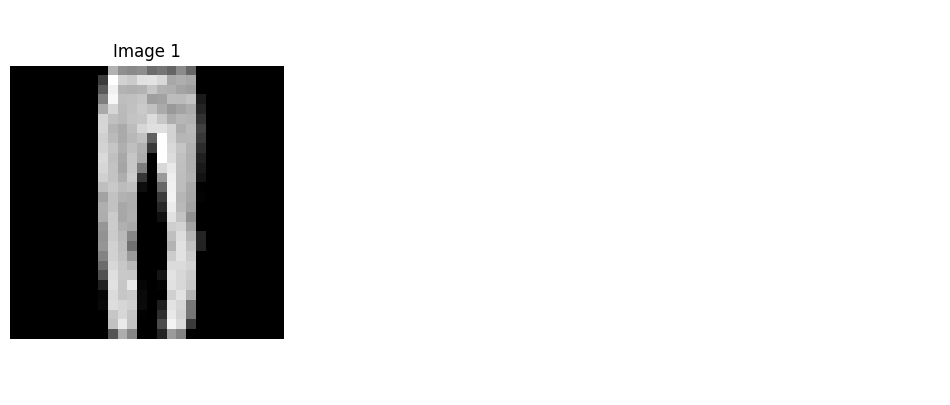

In [6]:
display_image(X[0])

À l'aide de la function `display_image` et de la fonction `mean` (**[documentation](https://numpy.org/doc/2.3/reference/generated/numpy.mean.html)**), affichez l'image moyenne.

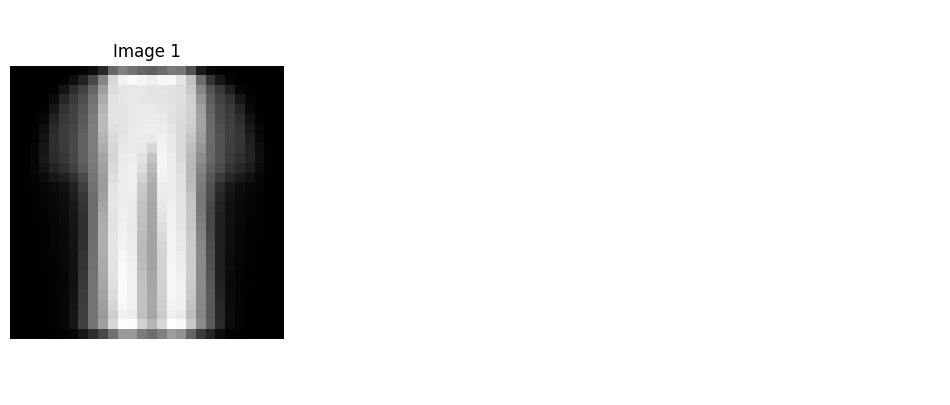

In [7]:
## Écrivez votre code ici.
display_image(np.mean(X,axis=0))

## Exercice 2

Construisez la fonction `random_centroids(data,k)` qui, à partir d'une matrice `data` et d'un entier `k`, renvoit une matrice consitituée de `k`lignes de `data` choisies aléatoirement. Vous pouvez utiliser la fonction `np.random.choice` (**[documentation](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html)**).

In [8]:
## Écrivez votre code ici.
def random_centroids(data,k):
  return data[np.random.choice(data.shape[0], size=k, replace=False)]

Testez votre fonction avec le code suivant.

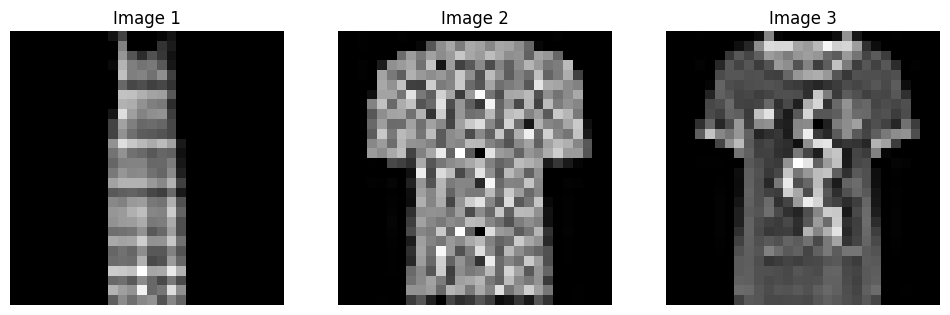

In [9]:
test_centroids = random_centroids(X,3)
display_image(test_centroids)

## Exercice 3

Construisez une fonction `assign_clusters(data,centroids)` qui, à partir d'une matrice `data` et d'une matrice `centroids`, renvoie un vecteur assignant à chaque ligne de `data` l'indice de la ligne de `centroids` avec laquelle elle a la plus petite distance euclidienne. Utilisez les fonctions `np.linalg.norm` (**[documentation](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html#numpy.linalg.norm)**) et `np.argmin` (**[documentation](https://numpy.org/doc/stable/reference/generated/numpy.argmin.html#numpy-argmin)**) (PAS DE BOUCLE FOR). C'est un exercice de broadcasting.

In [10]:
## Écrivez votre code ici.
def assign_clusters(data, centroids):
    n, d = data.shape
    # on prend nos n points, d caractéristiques
    k = centroids.shape[0]
    #nombre de centroïdes

    datareshape = data.reshape(n, 1, d)
     # on aura un datarreshape de taille (n, 1, d)
    centroidsreshape = centroids.reshape(1, k, d)
    # on aura un datareshape (1, k, d)

    distances = np.linalg.norm(datareshape- centroidsreshape, axis=2)
    # (n, k)
    indices= np.argmin(distances, axis=1)

    return indices


Construisez une fonction `pairing(data,centroids,n)` qui, à partir de matrices `data` et `centroids` ainsi qu'un entier `n`, affiche l'image correspondant à la ligne `n` de `data` et l'image correspondant à la ligne de `centroids` dont elle est la plus proche.

In [11]:
## Écrivez votre code ici.
def pairing(data, centroids, n):
  #on calcule la distance entre l'image n et tous les centroides
    distances = np.linalg.norm(centroids - data[n], axis=1)
    #et on veut prendre l'indice du centroide le plus proche
    indiceproche = np.argmin(distances)
    #içi on affiche l'image choisie (grâce à l'argument n de la fonction) et le centroide auquel elle correspond.
    display_image([data[n], centroids[indiceproche]])


Testez votre fonction avec le code suivant.

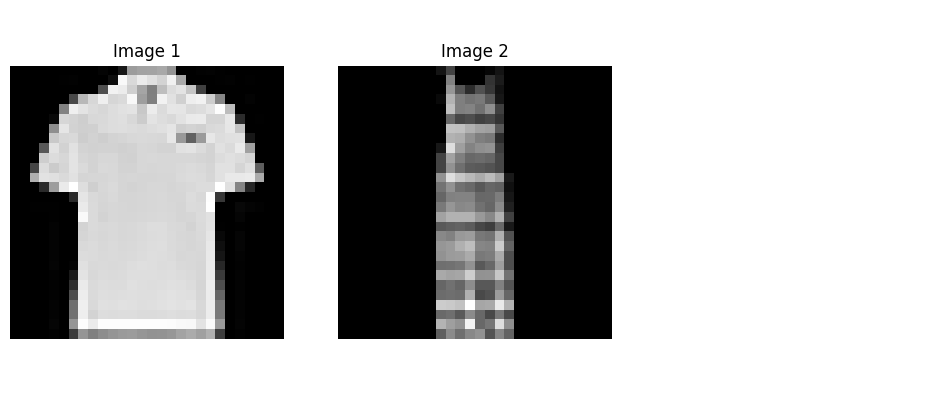

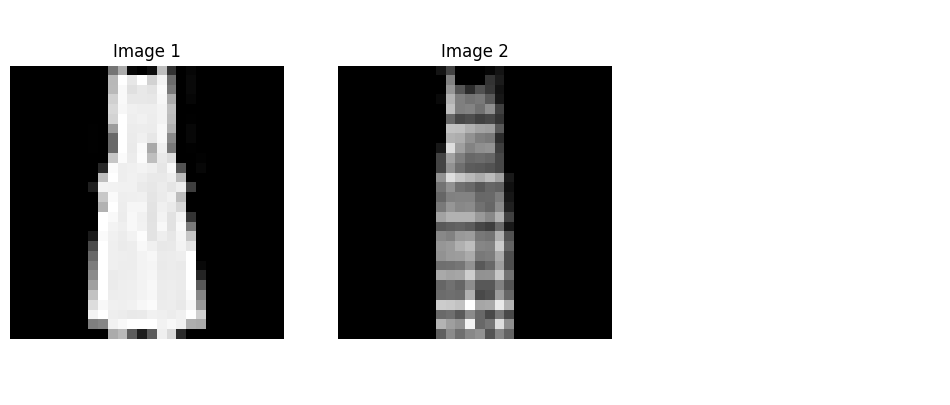

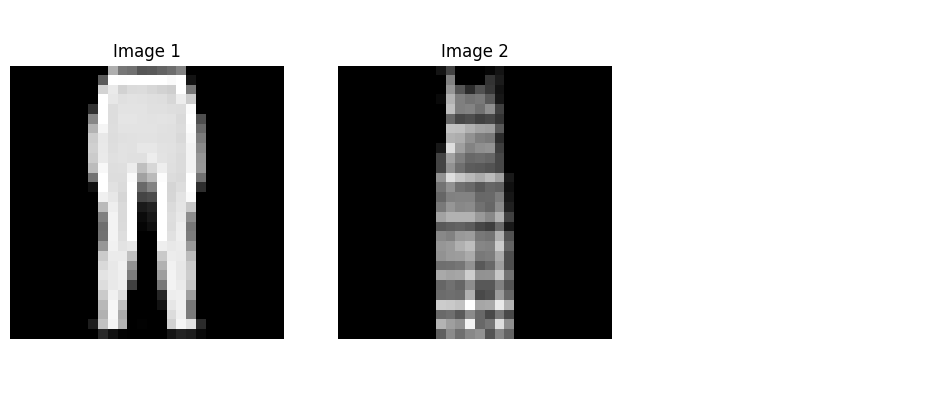

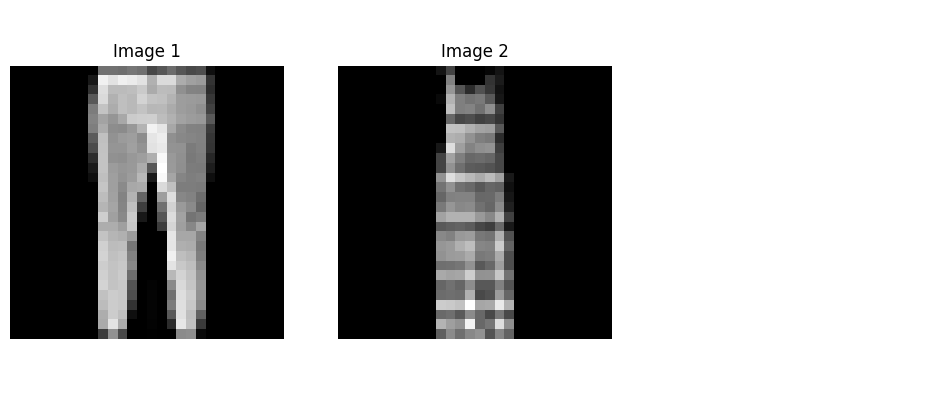

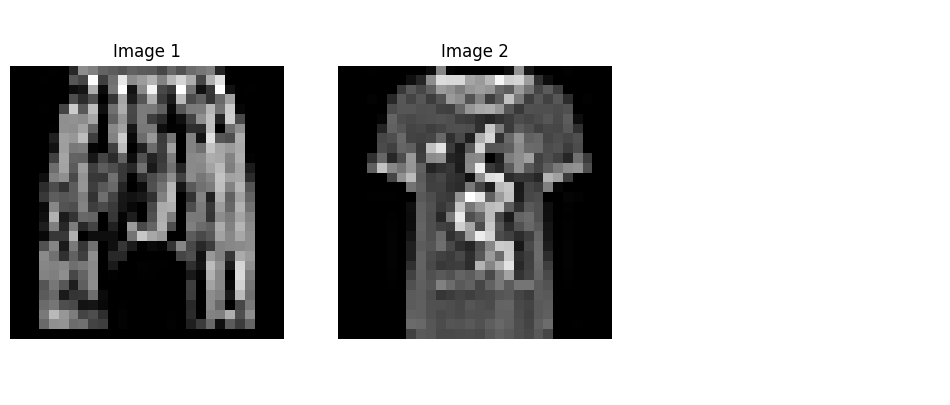

In [12]:
for _ in range(5):
    pairing(X,test_centroids,np.random.choice(range(X.shape[0])))

## Exerice 4

Construisez une fonction `update_centroids(data,k,labels)` qui, à partir d'une matrice `data`, d'un entier `k` et d'un vecteur `labels` assignant à chaque ligne de `data` un indice représentant un centroïde (parmi `k` possibles), renvoie une matrice avec `k` lignes représentant les nouveaux centroïdes après une itération de l'algorithme de Lloyd.

In [13]:
## Écrivez votre code ici.
def update_centroids(data,k,labels):
  n,m=data.shape
  nouveau_centroids=np.zeros((k,m))
  for j in range(k):
    #pour prendre toutes les images correspondants au cluster j
    point_du_cluster=data[labels==j]
    #le nouveau centroide devient la moyenne des images du cluster
    nouveau_centroids[j]= np.mean(point_du_cluster,axis=0)
  return nouveau_centroids




Testez votre fonction avec le code suivant.

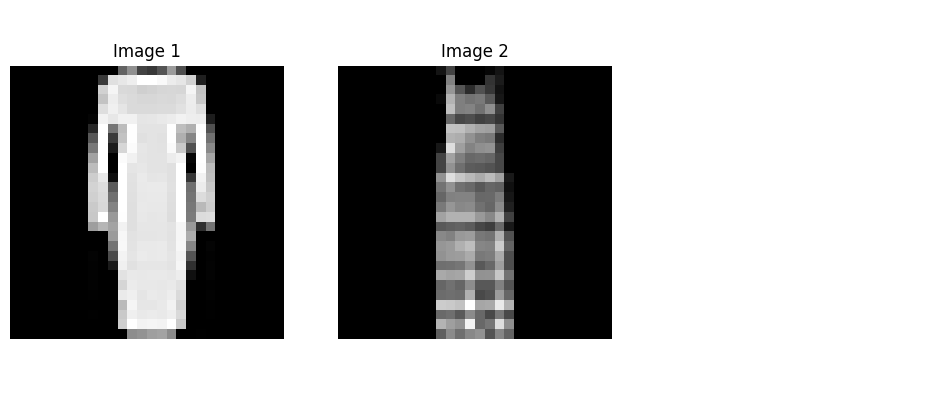

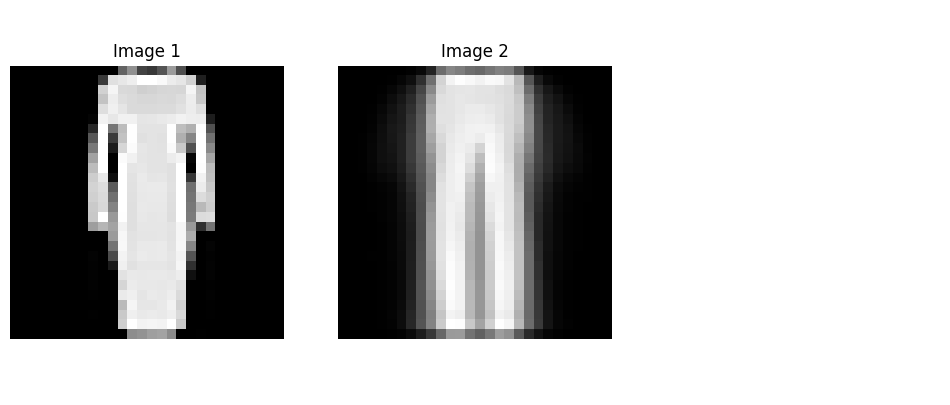

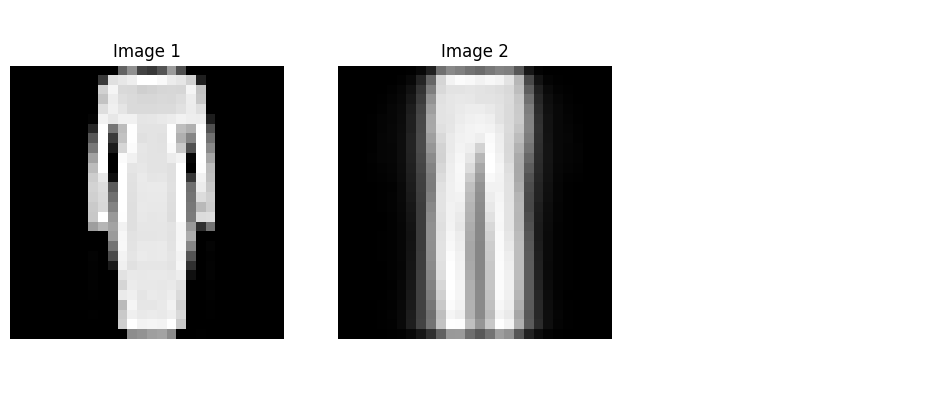

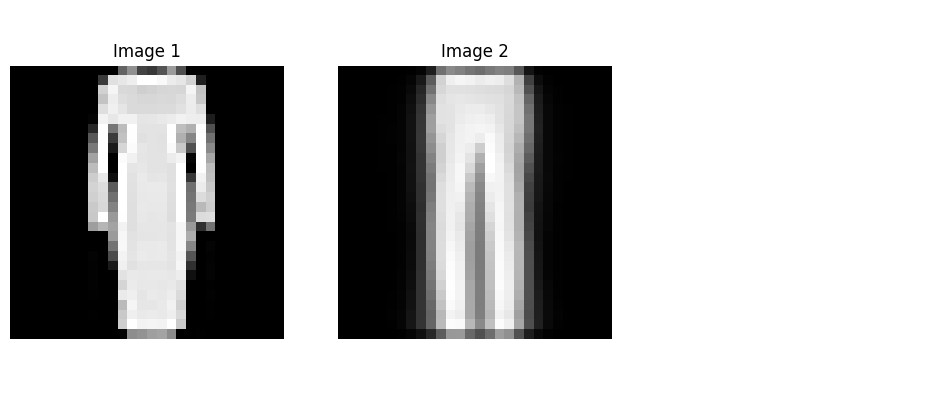

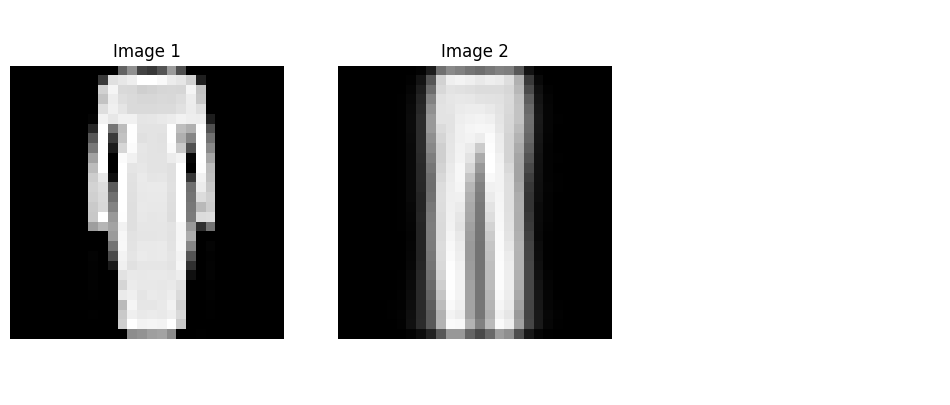

In [14]:
current_centroids = test_centroids
for _ in range(5):
    pairing(X,current_centroids,156)
    current_centroids = update_centroids(X,3,assign_clusters(X,current_centroids))

## Exercice 5

Nous allons commencer le Monkey-Patch de `MyKMeans`. La première étape est de construire une fonction `fit(self,data)` qui utilise l'algorithme de Lloyd pour assigner `self.labels` et `self.centroids` à partir d'une matrice de données `data`. Pour savoir quand arrêter l'algorithme, on utilise la convergence `self.tol` et le nombre maximal d'itération `self.max_iter`. La fonction se termine en affichant la raison de son arrêt ("Convergence atteinte à l'itération n" ou "Nombre maximal d'itération atteint").

In [15]:
   #on veut initialiser les centroides et repeter l'algo de Lloyd en mettant à jour les centroides
   #on s'arrete soit quand les centroides ne bougent plus avec la tolerance self.tol
   #ou quand on atteint le max_iteration
def fit(self, X):
#on veut d'abord avoir des centroides aléatoires de nos données en utilisant self.j de --init-- (le nombre de clusters)
  self.centroids = random_centroids(X, self.k)
  for i in range (self.max_iter):
    # on associe des points au cluster avec assign qui a un vecteur assigne à chaque ligne de data l'indice de la ligne de centroids avec laquelle elle a la plus petite distance euclidienne.
      self.labels=assign_clusters(X,self.centroids)
      copy_centroids=self.centroids.copy()

    #on modifie nos centroides en utilisant la fonction update
      self.centroids=update_centroids(X,self.k,self.labels)
      convergence=np.linalg.norm(self.centroids-copy_centroids)
    #la condition d'arret avec la tolerance
      if convergence<self.tol:
        print("Convergence atteinte a l'iteration ", i+1)
        return self

  print ("Nombre maximal d'itération atteinte")
  return self


MyKMeans.fit = fit

Une fois entrainé, un modèle de K-clustering peut aussi classer de nouvelles données. Il suffit de classer chaque vecteur dans la classe correspondant au centroïde dont il est le plus proche. Construisez une fonction `predict(self, new_data)` renvoyant le vecteur d'attribution d'indices de centroïdes. Si le modèle n'a pas encore été entrainé (par la fonction `fit`), faites apparaître un message d'erreur.

In [16]:
## Écrivez votre code ici.
def predict(self,new_data):
  #verifier que le modèle a d'abord était entrainé pour ne pas avoir self.centroids vide
  if self.centroids is None:
    print("il faut d'abord entrainé le modèle")
    return False
    #labels est le vecteur d'attrivution d'indices de centroides
  labels= assign_clusters(new_data,self.centroids)
  return labels

  MyKmeans.predic=predict

## Exercice 5

Il est temps d'appliquer ce modèle à nos données. Utilisez le code suivant pour classer nos images en trois groupes (en espérant trouver un groupe pour les T-shirts, un groupe pour les pantalons et un groupe pour les robes).

Nombre maximal d'itération atteinte


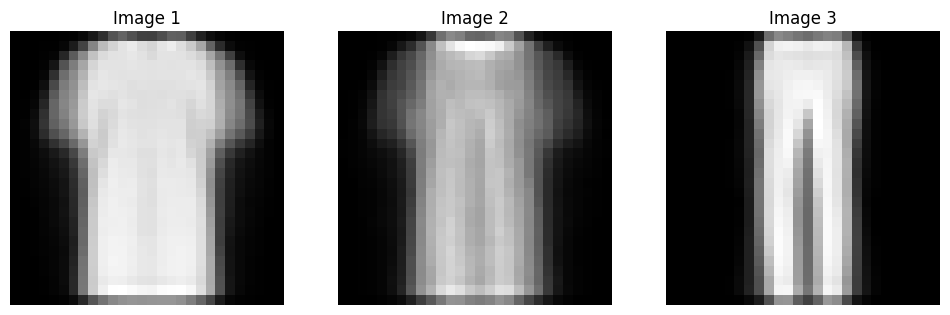

In [17]:
my_km = MyKMeans(n_clusters=3, max_iter=10)
my_km.fit(X)
display_image(my_km.centroids)

Pour évaluer les résulats, nous allons utiliser la véritable classification des données.

In [18]:
from google.colab import files
data_to_load2 = files.upload()
filename = list(data_to_load2.keys())[0]
df_labels = pd.read_csv(io.BytesIO(data_to_load2[filename]))

y = df_labels["label"].values

Saving labels.csv to labels.csv


Nous allons représenter les données dans un tableau de contingence croisant la classification du modèle de K-clustering et la véritable classification des images.

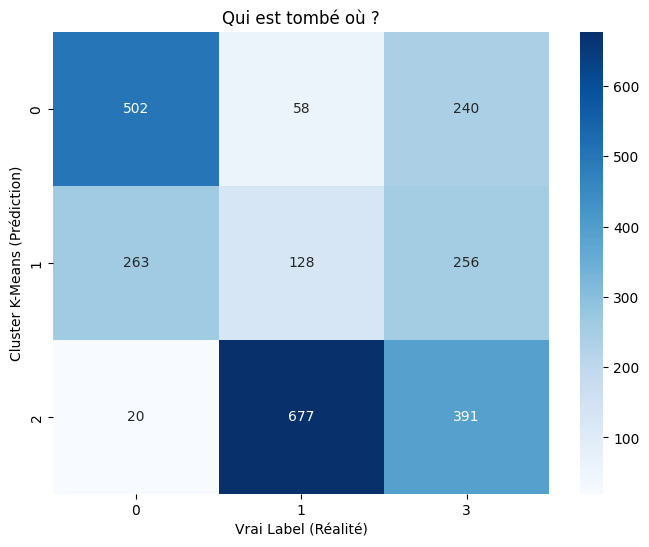

In [19]:
df_compare = pd.DataFrame({
    'Vrai Label': y,
    'Cluster KMeans': my_km.labels
})

ct = pd.crosstab(df_compare['Cluster KMeans'], df_compare['Vrai Label'])

plt.figure(figsize=(8, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title("Qui est tombé où ?")
plt.xlabel("Vrai Label (Réalité)")
plt.ylabel("Cluster K-Means (Prédiction)")
plt.show()

Si la classification était parfait, chaque ligne aurait exactement une case non-vide. Pour estimer à quel point une ligne est parfaite, nous pouvons donc considérer la part des éléments de cette ligne qui sont dans la case qui en contient le plus. En généralisant au tableau entier, nous pouvons estimer la précision du modèle en considérant la part des éléments du tableau qui sont dans la case majoritaire de leur ligne. Appelons cette mesure "précision du modèle".

In [20]:
row_maxes = ct.max(axis=1)
sum_of_maxes = row_maxes.sum()
total_elements = ct.values.sum()
proportion = sum_of_maxes / total_elements

print(f"Précision: {proportion:.2%}")

Précision: 56.88%


Pour améliorer les résultats, nous pouvons augmenter le nombre de centroïdes. Cela revient à découper chaque groupe en plusieurs sous-groupes, en supposant que l'algorithme d'apprentissage non-supervisé est plus efficace pour détecter plusieurs collections homogènes plutôt qu'un ensemble disparate. Construisez une fonction `test_accuracy(n)` créant une instance de `MyKMeans` avec `n` centroïdes, l'entrainant sur `X` et évaluant les résultats avec `y`. La fonction doit renvoyer la précision du modèle.

In [21]:
def test_accuracy(n):
    # on entraine k-means avec n centroïdes
    my_km = MyKMeans(n_clusters=n, max_iter=50)
    my_km.fit(X)

    # on construit le tableau de contingence de la même façon qu'avant
    ct = pd.crosstab(my_km.labels, y)

    # pour chaque cluster on prend le label  majoritaire
    row_maxes = ct.max(axis=1)

    sum_of_maxes = row_maxes.sum()

    # nombre total d'images
    total_elements = ct.values.sum()

    proportion = sum_of_maxes / total_elements

    return proportion







Testez votre fonction avec plusieurs valeurs de `n`. Augmentez `n` pas à pas car l'algorithme pourra prendre beaucoup de temps à tourner pour de hautes valeurs de `n`.

In [22]:
## Écrivez votre code ici.
for n in [2, 4, 8, 10, 15]:
    acc = test_accuracy(n)
    print(f"n = {n} -> precision = {acc:.2%}")

Convergence atteinte a l'iteration  15
n = 2 -> precision = 53.14%
Convergence atteinte a l'iteration  24
n = 4 -> precision = 76.57%
Convergence atteinte a l'iteration  30
n = 8 -> precision = 78.93%
Convergence atteinte a l'iteration  38
n = 10 -> precision = 77.36%
Convergence atteinte a l'iteration  25
n = 15 -> precision = 86.79%
